In [1]:
import sys
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D

sys.path.append('../..')

from src.piece_functions import generate_random_trajectory

from src.embedding_trans import EmbeddingTrans
from src.markov_analysis import MarkovFromEmbedding,MultiMarkov



/home/hugo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Generate trajectories
Here we study how changes in characteristics of the trajectory reflects in the markov model we derive later. To do so, we first build _ samples with the following characteristics:
1. This is a reference made only with persistent random walk and straight lines.
2. Same as first, with a different rate of straight lines.
3. Same as first, with a faster straight line.
4. same as first, but add helix

In [2]:
descriptions = ['straight and persistent', 'more frequent straight', 'longer straight','helix and persistent']
trjss,mvss = list(),list()

A = 0.1 # noise amplitude
ttot = 2000 # duration of each trajectory in timestep unit
nsample = 10 # number of trajectories

mvt_types = ['straight','persistent_random_walk']#,'helix','persistent_random_walk','cast_and_surge']
mvt_args = {'straight':{'n_steps':50,'step':1.,'distrib':'uniform'},
            'helix':{'radius':5,'pitch':5.,'distrib':'uniform','n_steps':50},
            'cast_and_surge':{'A0':10,'decay':0.025,'distrib':'unform'},
            'persistent_random_walk':{'turn_std':np.pi/5,'distrib':'uniform','n_steps':50}}
probabilities = [0.2,0.8]
trjs,mvs = list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)


# change the proba
probabilities = [0.5,0.5]
trjs,mvs=list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)
# reset
probabilities = [0.2,0.8]

# change the speed : changing the step size means going faster while
#                    keeping the picture rate constant.
mvt_args['straight'] = {'n_steps':50,'step':5.,'distrib':'uniform'}
trjs,mvs= list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)
#reset
mvt_args['straight'] = {'n_steps':50,'step':1.,'distrib':'uniform'}

# replace straight by helixes
mvt_types = ['persistent_random_walk','helix']
probabilities = [0.8,0.2]
trjs,mvs = list(),list()
for _ in range(nsample):
    trj, move_names = generate_random_trajectory(total_steps = ttot,
                                                    step_size=1.,
                                                    mvt_types = mvt_types,
                                                    probabilities=probabilities,
                                                    mvt_args=mvt_args)
    trjs.append(trj)
    mvs.append(move_names)
trjss.append(trjs)
mvss.append(mvs)
#reset
mvt_types = ['straight','persistent_random_walk']
probabilities = [0.1,0.9]

trjss = np.array(trjss)

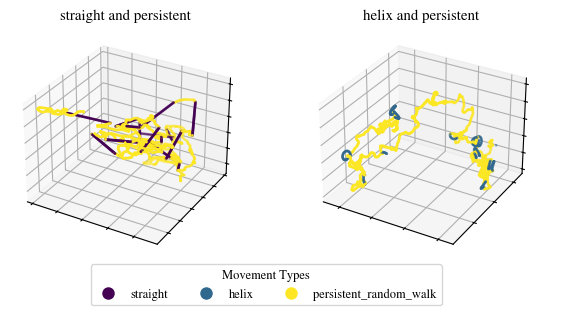

In [3]:
Ttot = 500
cmap = colormaps['viridis']
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'persistent_random_walk':cmap(1.)}
color_code = np.array([[clr_dict[mv] for mv in mvs[0]] for mvs in mvss])
fig,ax = plt.subplots(ncols=2,subplot_kw={'projection':'3d'},figsize=(7,3))
for i in [0,-1]:
    ax[i].scatter(trjss[i][0][:ttot,0],trjss[i][0][:ttot,1],trjss[i][0][:ttot,2],c=color_code[i][:ttot],s=1)
    ax[i].set_title(descriptions[i])
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([])
    ax[i].set_zticklabels([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=10)
    for key, color in clr_dict.items()
]
ax[0].legend(ncols=3,loc=(0.35,-0.2),handles=legend_elements, title="Movement Types")

#fig.savefig('toy_models.svg',transparent=True)

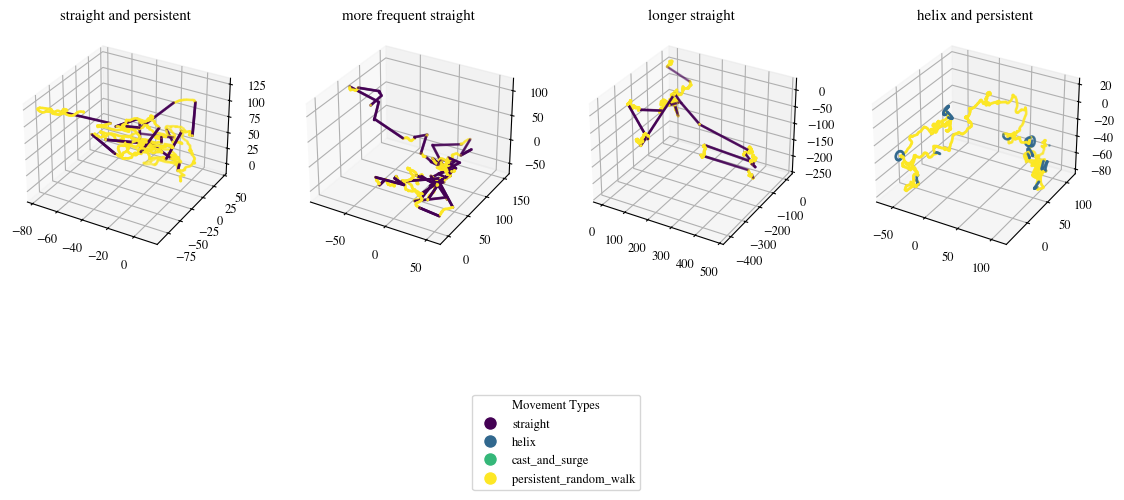

In [4]:

cmap = colormaps['viridis']
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'cast_and_surge':cmap(0.666),'persistent_random_walk':cmap(1.)}
color_code = np.array([[clr_dict[mv] for mv in mvs[0]] for mvs in mvss])
fig,ax = plt.subplots(ncols=4,subplot_kw={'projection':'3d'},figsize=(14,3))
for i in range(4):
    ax[i].scatter(trjss[i][0][:,0],trjss[i][0][:,1],trjss[i][0][:,2],c=color_code[i],s=1)
    ax[i].set_title(descriptions[i])


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=10)
    for key, color in clr_dict.items()
]
ax[0].legend(loc=(2.,-1.),handles=legend_elements, title="Movement Types")

In [5]:
labels = np.repeat(np.arange(nsample), ttot)
frames = np.tile(np.arange(ttot), nsample)

dfs = list()

for trjs,mvs in zip(trjss,mvss):
    flat_trjs = trjs.reshape(-1,3)
    flat_mvs = [item for sublist in mvs for item in sublist]
    df = pd.DataFrame(flat_trjs, columns=['x', 'y', 'z'])
    df['label'] = labels
    df['frame'] = frames
    df['move_type'] = flat_mvs
    dfs.append(df)

### Optimize the entropy production based on nc and K

columns_abs = []
columns_translated = ['x','y','z']
id = 'label'
time = 'frame'

Klist = [3,5,10,20]
nc_list = [10,20,50,100,200,1000]

embs = list()
for df in dfs:
    embs.append(EmbeddingTrans(df,columns=columns_abs,columns_translated=columns_translated,ID_NAME=id,label_col='move_type'))

H = np.zeros((len(embs),len(Klist),len(nc_list)),dtype=float)

for i,K in enumerate(Klist):
    print(i)
    for emb in embs:
        emb.make_embedding(K=K)
    for j,nc in enumerate(nc_list):
        for emb in embs:
            emb.make_cluster(n_clusters=nc)
        mkvs = list()
        for emb in embs:
            mkvs.append(MarkovFromEmbedding(emb,tau=1))
        for k,mkv in enumerate(mkvs):
            H[k,i,j] = mkv.compute_entropy_rate()

fig,ax = plt.subplots(ncols = len(embs),figsize=(4*len(embs),4))
for k in range(H.shape[0]):
    for i,h in enumerate(H[k]):
        ax[k].plot(nc_list,h,label=Klist[i])
    ax[k].legend()

### Build the different class instances

In [6]:
columns_abs = []
columns_translated = ['x','y','z']
id = 'label'
time = 'frame'

embs = list()
for df in dfs:
    embs.append(EmbeddingTrans(df,columns=columns_abs,columns_translated=columns_translated,ID_NAME=id,label_col='move_type'))

In [7]:
K_list = [10,10,10,10]
for i,emb in enumerate(embs):
    emb.make_embedding(K=K_list[i])
    emb.make_cluster(n_clusters=200)

In [8]:
tau_list = [1,2,3,4,5,6,7,8,9,10,15,20,25,50,100]
eig_vals_10 = list()
l_eig_vals_10 = list()
entropies_rates = list()
timescales = list()
for tau in tau_list:
    mkvs = list()
    for emb in embs:
        mkvs.append(MarkovFromEmbedding(emb,tau=tau))
    eig_val_10,l_eig_val_10,entropy_rate,timescale = list(),list(),list(),list()
    for mkv in mkvs:
        mkv.compute_spectrum()
        eig_val_10.append(mkv.eigvals[-10:])
        l_eig_val_10.append(mkv.l_eigvals[-10:])
        entropy_rate.append(mkv.compute_entropy_rate())
        timescale.append(mkv.implied_timescales(tau=tau))
    eig_vals_10.append(eig_val_10)
    l_eig_vals_10.append(l_eig_val_10)
    entropies_rates.append(entropy_rate)
    timescales.append(timescale)
eig_vals_10 = np.array(eig_vals_10)
l_eig_vals_10 = np.array(l_eig_vals_10)
entropies_rates = np.array(entropies_rates)
timescales = np.array(timescales)

In [9]:
from matplotlib import cm 
colors = cm.Reds(np.linspace(0.4, 0.9, 10))  # Gradient from light to dark red

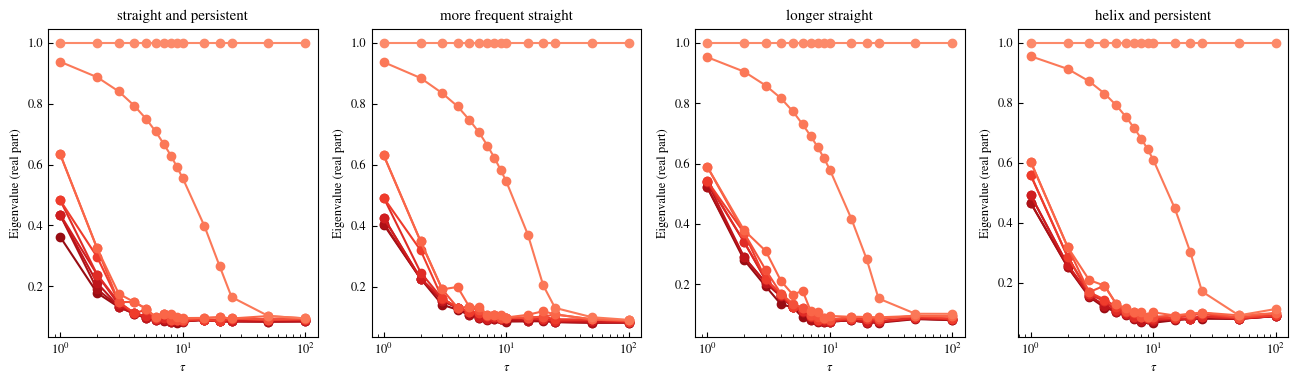

In [10]:
fig,ax = plt.subplots(ncols=4,nrows=1,figsize=(16,4))
for i in range(eig_vals_10.shape[2]):
    # Plot    
    for j in range(eig_vals_10.shape[1]):
        ax[j].plot(tau_list, eig_vals_10[:,j,i],marker='o', label=r"$\lambda_{"+str(i+1)+"}$",color=colors[9-i])    
        ax[j].set_xlabel("τ")
        ax[j].set_ylabel("Eigenvalue (real part)")
        ax[j].set_title(descriptions[j])
        ax[j].set_xscale('log')
        ax[j].set_xlabel(r'$\tau$')


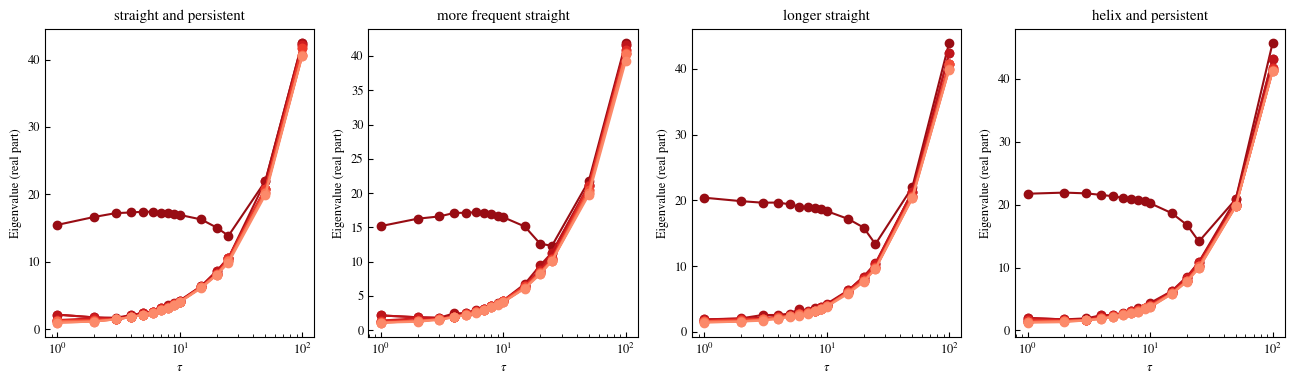

In [11]:
fig,ax = plt.subplots(ncols=4,nrows=1,figsize=(16,4))
for i in range(10):
    # Plot    
    for j in range(timescales.shape[1]):
        ax[j].plot(tau_list, timescales[:,j,i],marker='o', label=r"$\lambda_{"+str(i+1)+"}$",color=colors[9-i])    
        ax[j].set_xlabel("τ")
        ax[j].set_ylabel("Eigenvalue (real part)")
        ax[j].set_title(descriptions[j])
        ax[j].set_xscale('log')
        ax[j].set_xlabel(r'$\tau$')


# Look at how good is the usual paritioning

In [12]:
red_pts = list()
center_pts = list()
for emb in embs:
    pts,centers = emb.fit_umap(with_cluster_centers=True)
    red_pts.append(pts)
    center_pts.append(centers)

/home/hugo/miniconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/hugo/miniconda3/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


In [13]:
mkvs = list()
for emb in embs:
    mkvs.append(MarkovFromEmbedding(emb,tau=1))
partitions = list()
for i in range(len(mkvs)):
    print(i)
    partitions.append(mkvs[i].recursive_partition(2))

0
1
2
3


import h5py
import pickle
# store the embedding and markov inside a hdf5 file
output_filename = '../../data/toy_model/interim/nested_data.h5'

with h5py.File(output_filename, 'w') as hf:
    for i in [0,-1]:
        name = descriptions[i]
        # Create a group for this specific 'name' to keep things organized
        grp = hf.create_group(name)

        # Save to HDF5 group with compression (optional but recommended)
        grp.create_dataset('umap_points', data=red_pts[i], compression="gzip")
        grp.create_dataset('umap_centers', data=center_pts[i], compression="gzip")
        grp.create_dataset('color', data=clust_to_partitions[i][embs[i].labels], compression="gzip")

        emb_str = pickle.dumps(embs[i])
        grp.create_dataset('embedding', data=np.void(emb_str))

        mkv_str = pickle.dumps(mkvs[i])
        grp.create_dataset('markov', data=np.void(mkv_str))

print(f"Successfully packed data into {output_filename}")

In [14]:
clust_to_partitions = [[0 for _ in range(embs[i].n_clusters)] for i in range(len(embs))]

for i in range(4):
    for partition_idx, cluster_ids in enumerate(partitions[i]):
        for id in cluster_ids:
            clust_to_partitions[i][id] = partition_idx
clust_to_partitions = ak.Array(clust_to_partitions)

Text(0.5, 1.0, 'longer straight lines')

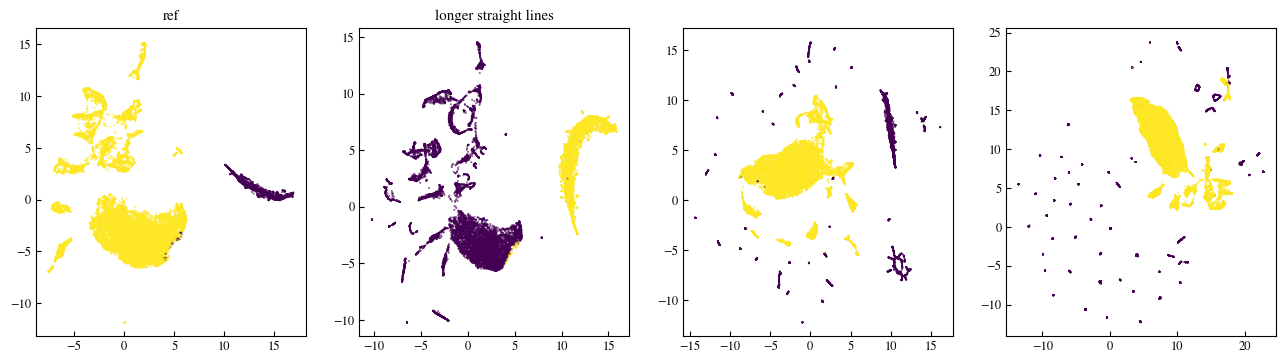

In [15]:
fig,ax = plt.subplots(ncols=4,figsize=(16,4))

for i in range(4):
    ax[i].scatter(red_pts[i][:,0],red_pts[i][:,1],s=0.1,c = clust_to_partitions[i][embs[i].labels])
ax[0].set_title('ref')
ax[1].set_title('longer straight lines')

In [37]:
print(set(color_values[0]))
print(cmap(0))
print(cmap(0.333))
print(cmap(1.))

{np.int64(0), np.int64(1)}
(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0))
(np.float64(0.190631), np.float64(0.407061), np.float64(0.556089), np.float64(1.0))
(np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))


In [ ]:
clr_dict ={'straight':cmap(0.),'helix':cmap(0.333),'persistent_random_walk':cmap(1.)}
traj_to_classify = list()
labels_classify = list()
color_values = list()
ind_list = [0,-1]
for i in ind_list:
    traj_to_classify.append(dfs[i][df["label"]==0][['x','y','z']].to_numpy())
for i in ind_list:
    labels_classify.append(embs[i].classify_trajectory(trajectory_trans=traj_to_classify[i]))
for i in ind_list:
    color_values.append(np.array([clust_to_partitions[i][lab] for lab in labels_classify[i]]))
#adjust the color_values to have helix in a different color
color_values[1] = (color_values[1]-1)**2*(0.333-1) +1

color_values = np.array([[cmap(np.float64(value)) for value in col_val] for col_val in color_values])

fig,ax = plt.subplots(nrows=2,ncols=len(ind_list),figsize=(len(ind_list)*3,6),subplot_kw={'projection':'3d'})
for i in ind_list:
    Imax = labels_classify[i].shape[0]
    x = traj_to_classify[i][:,0][:Imax]
    y = traj_to_classify[i][:,1][:Imax]
    z = traj_to_classify[i][:,2][:Imax]

    ax[0,i].scatter(x,y,z,c=color_code[i][:Imax],s=1)
    
    ax[1,i].scatter(x,y,z,c=color_values[i],s=1)  

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=key,
           markerfacecolor=color, markersize=10)
    for key, color in clr_dict.items()
]
#ax[1,0].legend(ncols=3,loc=(0.35,-0.2),handles=legend_elements, title="Movement Types")
fig.legend(handles=legend_elements, ncols=3, loc='lower center', bbox_to_anchor=(0.5, 0.02))

for i in range(2):
    for j in range(2):
        ax[i,j].set_xticklabels([])
        ax[i,j].set_yticklabels([])
        ax[i,j].set_zticklabels([])
        ax[i,j].set_xlabel('x',labelpad=-15)
        ax[i,j].set_ylabel('y',labelpad=-15)
        ax[i,j].set_zlabel('z',labelpad=-15)

# Centered title for the first row (Top)
fig.text(0.5, 0.9, 'Real Labels', ha='center', va='center', fontsize=9, fontweight='bold')

# Centered title for the second row (Bottom)
fig.text(0.5, 0.48, 'Classified Trajectories', ha='center', va='center', fontsize=9, fontweight='bold')

# Adjust layout to make room for titles
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

#plt.savefig('classification_trajectory.svg',transparent=True,bbox_inches='tight')

/tmp/ipykernel_10167/3772953662.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


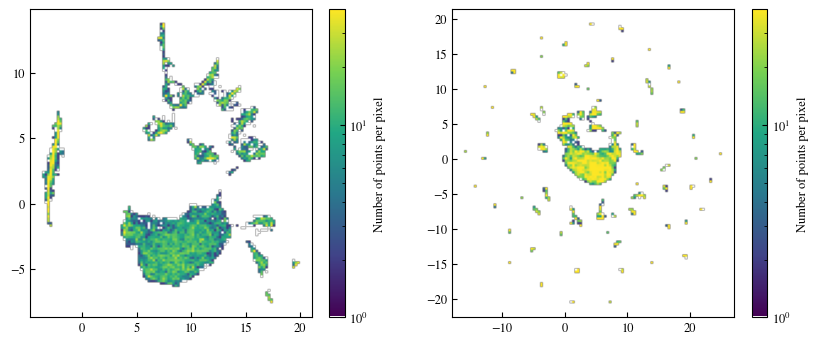

In [56]:
from matplotlib.colors import Normalize, LogNorm
import src.viz
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(2*5,4),subplot_kw={'projection':'scatter_density'})
norms = [LogNorm(vmin =1 ,vmax=40),LogNorm(vmin = 1,vmax=40)]
dpis = [50,50]
for i in [0,-1]:
    src.viz.use_mpl_scatter_density(fig,red_pts[i][:,0],red_pts[i][:,1],ax=ax[i],dpi=dpis[i],norm=norms[i])
    src.viz.zoom_out(ax[i],1.1)

In [214]:
clust_to_partitions[i][embs[i].labels].__len__()

19910

In [212]:
MKVs = list()
for i in range(clust_to_partitions.__len__()):
    MKVs.append(Markov(clust_to_partitions[i][embs[i].labels],2))

AttributeError: 'numpy.int64' object has no attribute '__len__'

### Clusterize them together

In [215]:
import importlib
import src.cluster
importlib.reload(src.cluster)
from src.cluster import Cluster
from scipy.special import entr

In [123]:
nc_com_list = [10,20,30,40,50,60,70,80,90,100,200,500,1000]
H_mix = list()
for nc in nc_com_list:
    clt = Cluster(nc)
    clt.add_embedding(embs[0])
    clt.add_embedding(embs[2])
    clt.set_shape_and_flatten()
    clt.clusterize()
    prop = clt.compute_proportions()
    H_mix.append((np.sum(entr(prop),axis=1)))
H_mix = ak.Array(H_mix)
#
#    mkv = Markov()

50


Text(0, 0.5, 'mixing entropy of the clusters')

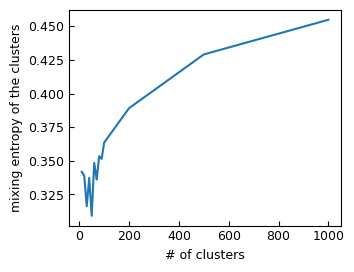

In [124]:
plt.plot(nc_com_list,ak.mean(H_mix,axis=1))
print(nc_com_list[np.argmin(ak.mean(H_mix,axis=1))])
plt.xlabel('# of clusters')
plt.ylabel('mixing entropy of the clusters')

In [227]:
clt = Cluster(400)
clt.add_embedding(embs[0])
clt.add_embedding(embs[2])
clt.set_shape_and_flatten()
clt.clusterize()


In [228]:
mmkv = MultiMarkov(clt,tau=1)

In [229]:
for i in range(mmkv.__len__()):
    print(mmkv[i].compute_entropy_rate())
print()
print(mkvs[0].compute_entropy_rate())
print(mkvs[1].compute_entropy_rate())

1.1604330312874471
1.8500171095778106

1.8363295831995496
1.274722857519979


In [219]:
h_list = np.sum(entr(clt.compute_proportions()),axis=1) # compute the mixing entropy of every cluster
partitions = list()
n_partition = 5
hmin = 10**-10
reduced_systems = list()
for i in range(mmkv.__len__()):
    print()
    # add a loop to isolate the empty clusters
    keep = True
    isolated =list() # store the isolated clusters
    reduced_system = np.arange(mmkv[i].n_clusters) # start by considering every cluster
    while keep:
        partition = mmkv[i].recursive_partition(2,reduced_system = reduced_system)
        for part in partition:
            if all(h_list[part] <=hmin):
                keep = True
                for val in part:
                    reduced_system = reduced_system[~np.isin(reduced_system, part)]
                break
            keep = False
    reduced_systems.append(reduced_system)


In [230]:
partitions= list()
for i in range(len(mmkv)):
    partitions.append(mmkv[i].recursive_partition(2,reduced_system = reduced_systems[i]))

In [234]:
clt.fit_umap(with_cluster_centers=False)

/home/hugo/miniconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


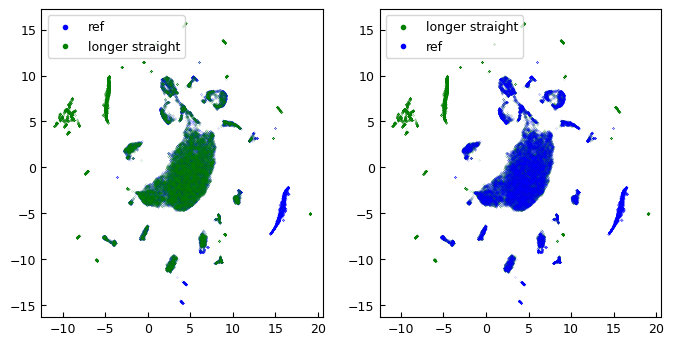

In [222]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].scatter(ak.flatten(clt.reduced_pts[0])[:,0],ak.flatten(clt.reduced_pts[0])[:,1],s=0.01,alpha=1.,c='b',label='ref')
ax[0].scatter(ak.flatten(clt.reduced_pts[1])[:,0],ak.flatten(clt.reduced_pts[1])[:,1],s=0.01,alpha=1.,c='g',label='longer straight')

ax[1].scatter(ak.flatten(clt.reduced_pts[1])[:,0],ak.flatten(clt.reduced_pts[1])[:,1],s=0.01,alpha=1.,c='g',label='longer straight')
ax[1].scatter(ak.flatten(clt.reduced_pts[0])[:,0],ak.flatten(clt.reduced_pts[0])[:,1],s=0.01,alpha=1.,c='b',label='ref')

ax[0].legend(markerscale=30)
ax[1].legend(markerscale=30)



Text(0.5, 1.0, 'longer straight lines')

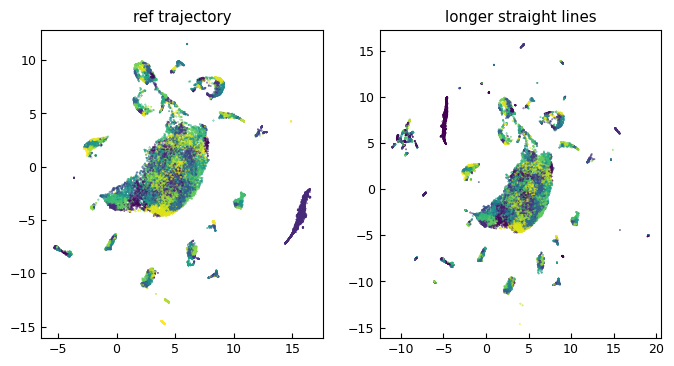

In [223]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))

for i in range(2):
    ax[i].scatter(ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],s=0.1,c = ak.flatten(clt.labels[i]))
ax[0].set_title('ref trajectory')
ax[1].set_title('longer straight lines')

In [231]:
cluster_to_partition = np.zeros((2,clt.n_clusters), dtype=int)

for i in range(2):
    for partition_idx, cluster_ids in enumerate(partitions[i]):
        cluster_to_partition[i][cluster_ids] = partition_idx

In [232]:
partition_labels = list()
for i in range(2):
    partition_labels.append(ak.Array([cluster_to_partition[i,labels] for labels in clt.labels[i]]))

Text(0.5, 1.0, 'longer straight lines')

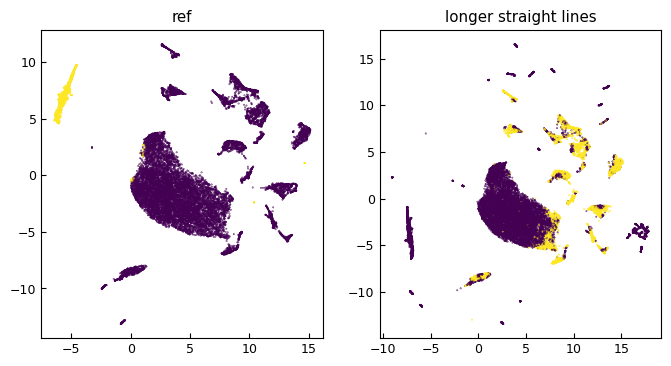

In [235]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))

for i in range(2):
    ax[i].scatter(ak.flatten(clt.reduced_pts[i])[:,0],ak.flatten(clt.reduced_pts[i])[:,1],s=0.1,c = ak.flatten(partition_labels[i]))
ax[0].set_title('ref')
ax[1].set_title('longer straight lines')

In [137]:
set(ak.flatten(partition_labels[0]))

{np.int64(0), np.int64(1)}

In [138]:
from src.markov_analysis import Markov
from src.trajectory_utils import count_transitions

In [139]:
MKVs = list()
for i in range(partition_labels.__len__()):
    MKVs.append(Markov(partition_labels[i],2))

In [140]:
name = ['ref','longer trajectory']
print('coarse grained stochastic matrices')
print('---------------')
i=0
for MKV in MKVs:
    MKV.reversibilized_matrix()
    print(name[i])
    print(MKV.P)
    print('---------------')
    i+=1

coarse grained stochastic matrices
---------------
ref
[[0.98926127 0.01073873]
 [0.06266938 0.93733062]]
---------------
longer trajectory
[[0.91341579 0.08658421]
 [0.12075788 0.87924212]]
---------------


In [141]:
for MKV in MKVs:
    print(MKV.implied_timescales(tau=3))

[39.34836219]
[12.9108036]


In [142]:
name = ['ref','longer trajectory']
print('equilibrium distributions')
print('---------------------')
i=0
for MKV in MKVs:
    print(name[i])
    print(MKV.pi)
    print('---------------------')
    i+=1

equilibrium distributions
---------------------
ref
[0.85371193 0.14628807]
---------------------
longer trajectory
[0.58240893 0.41759107]
---------------------


In [96]:
move_to_int = {'straight':0,'persistent_random_walk':1,'cast_and_surge':2,'helix':3}
true_labels = list()
for emb in [embs[0],embs[2]]:
    true_labels.append([[move_to_int[lab[0]] for lab in traj] for traj in emb.embedding_labels])

In [97]:
true_MKVs = list()
for i in range(true_labels.__len__()):
    true_MKVs.append(Markov(true_labels[i],2))

In [98]:
i=0
name = ['ref','longer trajectory']
print('equilibrium distributions')
print('---------------------')
for MKV in true_MKVs:
    #MKV.reversibilized_matrix()
    #print(MKV.P)
    #print()
    #print(MKV.Pr)
    print(name[i])
    print('---------------------')
    print(MKV.pi)
    print('---------------------')
    print()
    i+=1

equilibrium distributions
---------------------
ref
---------------------
[0.20992915 0.79007085]
---------------------

longer trajectory
---------------------
[0.20146465 0.79853535]
---------------------

